<a href="https://colab.research.google.com/github/sanjay11082006/salivary-ferning-mobilenet-classification/blob/main/salivary_ferning_mobilenet_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Done!")
print("Fern images:", len(os.listdir('dataset/fern')))
print("No fern images:", len(os.listdir('dataset/no_fern')))

Saving dataset.zip to dataset.zip
Done!
Fern images: 30
No fern images: 59


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom, RandomContrast
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. Define the Data Augmentation Pipeline
data_augmentation = Sequential([
    RandomFlip('horizontal_and_vertical'),
    RandomRotation(factor=0.2),
    RandomZoom(height_factor=0.15, width_factor=0.15),
    RandomContrast(factor=0.2)
], name="augmentation_layer")

# 2. Setup Base Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 3. Integrate Augmentation directly as the first layer
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # First layer
x = base_model(x, training=False) # Base model
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Verify structure
model.summary()

# 4. Data Loading (Requires dataset/ folder)
dataset_path = 'dataset/'
if os.path.exists(dataset_path):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    train_data = datagen.flow_from_directory(dataset_path, target_size=(224, 224), batch_size=8, class_mode='binary', subset='training')
    val_data = datagen.flow_from_directory(dataset_path, target_size=(224, 224), batch_size=8, class_mode='binary', subset='validation')

    print("\nStarting training with integrated augmentation...")
    model.fit(train_data, epochs=5, validation_data=val_data)
else:
    print(f"\n[!] '{dataset_path}' not found. Please upload your images to training the model.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_layer (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Found 72 images belonging to 2 classes.
Found 17 images belonging to 2 classes.

Starting training with integrated augmentation...
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.7500 - loss: 0.5903 - val_accuracy: 0.6471 - val_loss: 0.5262
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7222 - loss: 0.5264 - val_accuracy: 0.8235 - val_loss: 0.4895
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8472 - loss: 0.3781 - val_accuracy: 0.7059 - val_loss: 0.5836
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8611 - loss: 0.3867 - val_accuracy: 0.6471 - val_loss: 0.5998
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8889 - loss: 0.3381 - val_accuracy: 0.7059 - val_loss: 0.6309


### 1. Advanced Evaluation Metrics
Accuracy can be misleading if the dataset is small or imbalanced. We use a Confusion Matrix and Classification Report to get a deeper look at the performance.

Found 17 images belonging to 2 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step


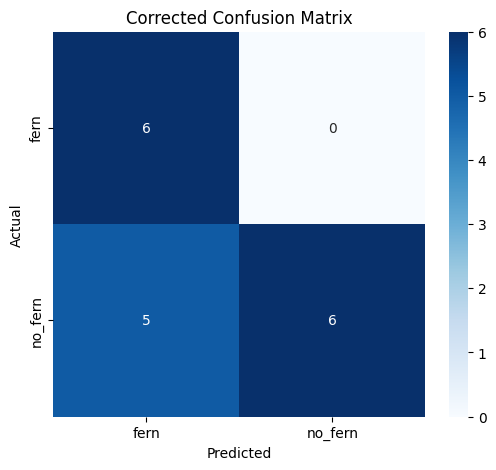


Classification Report (Corrected):
              precision    recall  f1-score   support

        fern       0.55      1.00      0.71         6
     no_fern       1.00      0.55      0.71        11

    accuracy                           0.71        17
   macro avg       0.77      0.77      0.71        17
weighted avg       0.84      0.71      0.71        17



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Re-create val_data without shuffling for accurate evaluation
eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_val_data = eval_datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

# Get correct predictions
y_pred_probs = model.predict(eval_val_data)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=eval_val_data.class_indices.keys(),
            yticklabels=eval_val_data.class_indices.keys())
plt.title('Corrected Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print('\nClassification Report (Corrected):')
print(classification_report(y_true, y_pred, target_names=eval_val_data.class_indices.keys()))

### 2. Single Image Inference
Use this cell to test the model on a single image file. The function will automatically load the saved model if it isn't currently in memory.

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

def predict_image(img_path):
    global model
    # If model is not in memory, try to load it from the saved file
    if 'model' not in globals():
        if os.path.exists('fern_model.keras'):
            print("Model variable not found. Loading from 'fern_model.keras'...")
            model = tf.keras.models.load_model('fern_model.keras')
        else:
            print("Error: The 'model' variable is not defined and 'fern_model.keras' was not found.")
            return

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    class_name = "No Fern" if prediction > 0.5 else "Fern"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    plt.imshow(img)
    plt.title(f"Prediction: {class_name} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

### 3. Test with Your Own Image
Run this cell to upload an image and see if the model identifies it as a **Fern** or **No Fern**.

Saving jk.jpg to jk (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


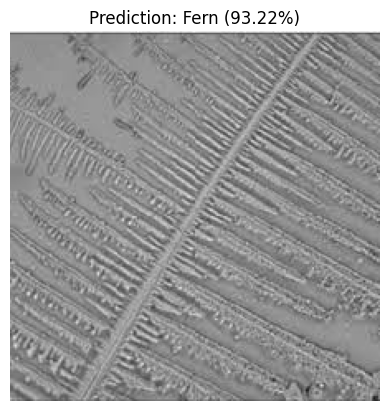

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

def predict_image(img_path):
    global model
    if 'model' not in globals():
        if os.path.exists('fern_model.keras'):
            model = tf.keras.models.load_model('fern_model.keras')
        else:
            print("Error: Model not trained or saved.")
            return

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    class_name = "No Fern" if prediction > 0.5 else "Fern"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    plt.imshow(img)
    plt.title(f"Prediction: {class_name} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

uploaded_test = files.upload()
for fn in uploaded_test.keys():
    predict_image(fn)

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def get_clean_gradcam(model, img_path, target_size=(224, 224)):
    # 1. Load and preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Extract the nested MobileNet base dynamically
    base_model = None
    for layer in model.layers:
        if "mobilenet" in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        raise ValueError("Could not locate the MobileNetV2 base layer in your model.")

    # 3. Target the 'Conv_1' or 'out_relu' layer inside the base model
    target_layer = None
    for layer in base_model.layers:
        if layer.name.startswith("Conv_1") or layer.name == "out_relu":
            target_layer = layer
            break

    # 4. Build a clean multi-output tracking sub-model targeting the base architecture
    # This maps the raw input directly to the Conv_1 output, ignoring the augmentation graph
    grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[target_layer.output, base_model.output]
    )

    # 5. Extract the classification head layers from your main sequential wrapper
    head_layers = []
    found_base = False
    for layer in model.layers:
        if "mobilenet" in layer.name.lower():
            found_base = True
            continue
        if found_base:
            head_layers.append(layer)

    # 6. Run GradientTape eagerly using our sub-model outputs
    with tf.GradientTape() as tape:
        # Step A: Pass image directly into the base sub-model inputs
        conv_outputs, base_predictions = grad_model(img_array, training=False)
        tape.watch(conv_outputs)

        # Step B: Run the head classification logic on the base predictions
        x = base_predictions
        for layer in head_layers:
            x = layer(x, training=False)

        # Pull the scalar output probability
        prediction_score = x[0]

    # 7. Calculate exact gradients
    grads = tape.gradient(prediction_score, conv_outputs)

    # 8. Compute Grad-CAM heat matrix math
    cast_conv_outputs = tf.cast(conv_outputs, tf.float32)
    cast_grads = tf.cast(grads, tf.float32)
    guided_grads = cast_conv_outputs * cast_grads * tf.cast(cast_grads > 0, tf.float32)

    weights = tf.reduce_mean(guided_grads[0], axis=(0, 1))
    cam = tf.reduce_sum(weights * cast_conv_outputs[0], axis=-1)

    # 9. Normalize the attention weights matrix
    cam = np.maximum(cam, 0)
    if np.max(cam) != 0:
        cam = cam / np.max(cam)
    cam = cv2.resize(cam, target_size)

    # 10. Generate overlays
    heatmap = np.uint8(255 * cam)
    colored_heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    colored_heatmap = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)

    original_img = np.uint8(img_array[0])
    superimposed_img = cv2.addWeighted(original_img, 0.6, colored_heatmap, 0.4, 0)

    # 11. Plot results
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(original_img)
    ax[0].set_title("Original Image View")
    ax[0].axis("off")

    ax[1].imshow(superimposed_img)
    ax[1].set_title("Model Focus (Grad-CAM)")
    ax[1].axis("off")
    plt.show()

print("🚀 Bulletproof Grad-CAM initialized. No loops, no positional argument errors!")

🚀 Bulletproof Grad-CAM initialized. No loops, no positional argument errors!


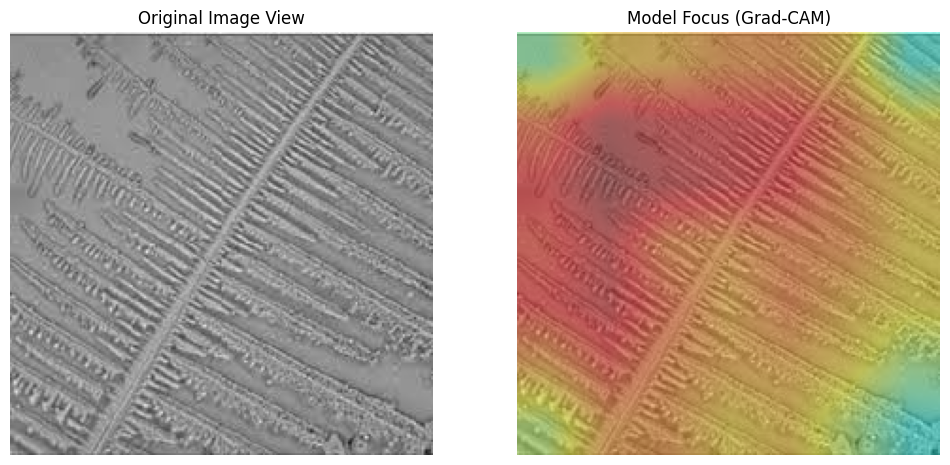

In [ ]:
# The cloud path after uploading to the Colab sidebar
my_test_image = '/content/jk.jpg'

# Run the heatmap function
get_clean_gradcam(model, my_test_image)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_cow_saliva(model, img_path):
    # 1. Load and prepare the image exactly like training
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # 2. Get the model's raw probability score
    # (Since it's a binary dense layer with 1 output unit)
    raw_prediction = model.predict(img_array)[0][0]

    # 3. Convert probability to class labels and confidence percentages
    if raw_prediction >= 0.5:
        class_label = "No-Fern (Potential Pregnancy)"
        confidence = raw_prediction * 100
    else:
        class_label = "Fern (Estrus / Not Pregnant)"
        confidence = (1 - raw_prediction) * 100

    # 4. Plot the output nicely for your report
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {class_label}\nConfidence: {confidence:.2f}%", fontsize=12, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()

print("🎯 Live Inference Demo Loaded! Ready to test images.")

🎯 Live Inference Demo Loaded! Ready to test images.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


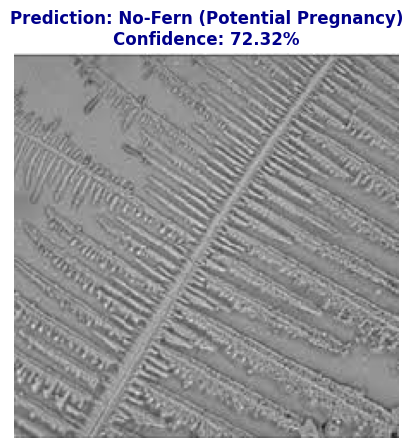

In [ ]:
predict_cow_saliva(model, '/content/jk.jpg')

### 4. Save and Download Model
This cell saves the trained model to the Colab environment and triggers a download to your local machine.

In [ ]:
# Save the model
model.save('fern_model.keras')
print("Model saved as fern_model.keras")

# Download to local computer
from google.colab import files
files.download('fern_model.keras')

Model saved as fern_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>